In [6]:
# =========================================================
# IMPORTACIÓN DE LIBRERÍAS
# =========================================================

# Importa pandas para manejar tablas
import pandas as pd

# Importa NumPy para cálculos numéricos
import numpy as np

# Importa herramientas estadísticas de SciPy
from scipy import stats

# =========================================================
# TABLA DE DATOS
# =========================================================

# Datos experimentales corregidos
datos = pd.DataFrame({

    # Masa del hielo en kg
    "m_hielo": [0.10745, 0.07845, 0.03596],

    # Masa del agua en kg
    "M_agua": [0.17027, 0.042700, 0.01373],

    # Masa del calorímetro en kg
    "M_cal": [0.32145, 0.30411, 0.28925],

    # Temperatura inicial en °C
    "Ti": [78.00000, 66.60000, 82.00000],

    # Temperatura final en °C
    "Tf": [29.00000, 6.00000, 30.00000]
})

# =========================================================
# CONSTANTES FÍSICAS
# =========================================================

# Calor específico del agua
c_agua = np.float64(4186)

# Calor específico del calorímetro
c_cal = np.float64(900)

# =========================================================
# INCERTIDUMBRES
# =========================================================

# Incertidumbre instrumental de masa
delta_m = np.float64(5e-6)

# Incertidumbre instrumental de temperatura
delta_T = np.float64(0.05)

# =========================================================
# MOSTRAR INCERTIDUMBRES
# =========================================================

print("="*70)
print("INCERTIDUMBRES INSTRUMENTALES")
print("="*70)

print(f"\nΔm = {delta_m:.0e} kg")
print(f"ΔT = {delta_T:.2f} °C")

# =========================================================
# MOSTRAR MEDICIONES
# =========================================================

print("\n" + "="*70)
print("MEDICIONES EXPERIMENTALES")
print("="*70)

# Recorre las filas del DataFrame
for i, fila in datos.iterrows():

    print(f"\n--------------- MEDICIÓN {i+1} ---------------")

    print(
        f"m_hielo = ({fila['m_hielo']:.5f} ± {delta_m:.6f}) kg"
    )

    print(
        f"M_agua = ({fila['M_agua']:.5f} ± {delta_m:.6f}) kg"
    )

    print(
        f"M_cal = ({fila['M_cal']:.5f} ± {delta_m:.6f}) kg"
    )

    print(
        f"Ti = ({fila['Ti']:.5f} ± {delta_T:.2f}) °C"
    )

    print(
        f"Tf = ({fila['Tf']:.5f} ± {delta_T:.2f}) °C"
    )

# =========================================================
# CÁLCULO DEL CALOR LATENTE
# =========================================================

print("\n" + "="*70)
print("CÁLCULO DEL CALOR LATENTE")
print("="*70)

# Lista para guardar resultados
Lf = []

# Recorre las mediciones
for i, fila in datos.iterrows():

    print(f"\n--------------- MEDICIÓN {i+1} ---------------")

    # Extrae variables
    mh = fila["m_hielo"]

    M = fila["M_agua"]

    Mcal = fila["M_cal"]

    Ti = fila["Ti"]

    Tf = fila["Tf"]

    # =====================================================
    # FÓRMULA
    # =====================================================

    print(r"""

                (Mc_agua + M'c_cal)(Ti - Tf)
    Lf = ------------------------------------------------
                  - mh*c_agua*Tf
                       ----------------
                              mh

    """)

    # =====================================================
    # SUSTITUCIÓN NUMÉRICA
    # =====================================================

    print("Sustituyendo:\n")

    print(
        f"Lf = [(({M:.5f})(4186) + ({Mcal:.5f})(900))"
    )

    print(
        f"({Ti:.5f} - {Tf:.5f})"
    )

    print(
        f"- ({mh:.5f})(4186)({Tf:.5f})] / ({mh:.5f})"
    )

    # =====================================================
    # CÁLCULO
    # =====================================================

    numerador = (
        (M*c_agua + Mcal*c_cal)*(Ti - Tf)
        - mh*c_agua*Tf
    )

    Lf_i = numerador / mh

    # Guarda resultado
    Lf.append(Lf_i)

    print(f"\nLf = {Lf_i:.5e} J/kg")

# Convierte lista a arreglo NumPy
Lf = np.array(Lf, dtype=np.float64)

# =========================================================
# PROMEDIO EXPERIMENTAL
# =========================================================

promedio = np.mean(Lf)

print("\n" + "="*70)
print("PROMEDIO EXPERIMENTAL")
print("="*70)

print(f"\nLf_promedio = {promedio:.5e} J/kg")

# =========================================================
# ANÁLISIS ESTADÍSTICO
# =========================================================

print("\n" + "="*70)
print("ANÁLISIS ESTADÍSTICO")
print("="*70)

# Desviación estándar muestral
desviacion = np.std(Lf, ddof=1)

# Error estándar
error_estandar = stats.sem(Lf)

# Intervalo de confianza al 95%
intervalo = stats.t.interval(

    confidence=0.95,

    df=len(Lf)-1,

    loc=np.mean(Lf),

    scale=error_estandar
)

print(f"\nDesviación estándar = {desviacion:.5e} J/kg")

print(f"\nError estándar = {error_estandar:.5e} J/kg")

print("\nIntervalo de confianza al 95%:")

print(
    f"[{intervalo[0]:.5e}, {intervalo[1]:.5e}] J/kg"
)

# =========================================================
# ERROR PORCENTUAL
# =========================================================

print("\n" + "="*70)
print("ERROR PORCENTUAL")
print("="*70)

# Valor teórico
L_teo = np.float64(3.34800e5)

# Error porcentual
error = np.abs((promedio - L_teo)/L_teo) * 100

print("\nValor teórico:")
print("L_teo = 3.34800×10^5 J/kg")

print("\nPromedio experimental:")
print(f"L_prom = {promedio/1e5:.5f}×10^5 J/kg")

print("\nFórmula:")

print(r"""
% error =
| (L_prom - L_teo) / L_teo | ×100
""")

print("\nSustituyendo:")

print(f"""
% error =
| ({promedio:.5e} - {L_teo:.5e})
 / ({L_teo:.5e}) |
×100
""")

print(f"\n% error = {error:.5f}%")

# =========================================================
# INTERPRETACIÓN
# =========================================================

print("\n" + "="*70)
print("INTERPRETACIÓN")
print("="*70)

print(f"""
El porcentaje de error obtenido fue de {error:.5f}%.

Esto indica que el valor experimental del calor
latente de fusión del hielo presenta una buena
aproximación respecto al valor teórico reportado
en la literatura.

La diferencia observada puede atribuirse a errores
instrumentales, pérdidas de calor hacia el ambiente,
transferencia térmica imperfecta y limitaciones
propias del montaje experimental.

Con ayuda de NumPy se realizaron los cálculos
numéricos y estadísticos básicos, mientras que
SciPy permitió calcular el error estándar y el
intervalo de confianza asociado a las mediciones.

Debido a que el porcentaje de error es relativamente
pequeño, se concluye que el procedimiento
experimental fue adecuado y los resultados obtenidos
son consistentes y confiables.
""")

INCERTIDUMBRES INSTRUMENTALES

Δm = 5e-06 kg
ΔT = 0.05 °C

MEDICIONES EXPERIMENTALES

--------------- MEDICIÓN 1 ---------------
m_hielo = (0.10745 ± 0.000005) kg
M_agua = (0.17027 ± 0.000005) kg
M_cal = (0.32145 ± 0.000005) kg
Ti = (78.00000 ± 0.05) °C
Tf = (29.00000 ± 0.05) °C

--------------- MEDICIÓN 2 ---------------
m_hielo = (0.07845 ± 0.000005) kg
M_agua = (0.04270 ± 0.000005) kg
M_cal = (0.30411 ± 0.000005) kg
Ti = (66.60000 ± 0.05) °C
Tf = (6.00000 ± 0.05) °C

--------------- MEDICIÓN 3 ---------------
m_hielo = (0.03596 ± 0.000005) kg
M_agua = (0.01373 ± 0.000005) kg
M_cal = (0.28925 ± 0.000005) kg
Ti = (82.00000 ± 0.05) °C
Tf = (30.00000 ± 0.05) °C

CÁLCULO DEL CALOR LATENTE

--------------- MEDICIÓN 1 ---------------


                (Mc_agua + M'c_cal)(Ti - Tf)
    Lf = ------------------------------------------------
                  - mh*c_agua*Tf
                       ----------------
                              mh

    
Sustituyendo:

Lf = [((0.17027)(4186) + (0.

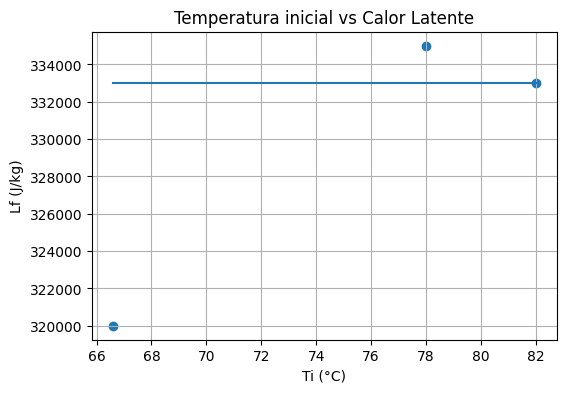

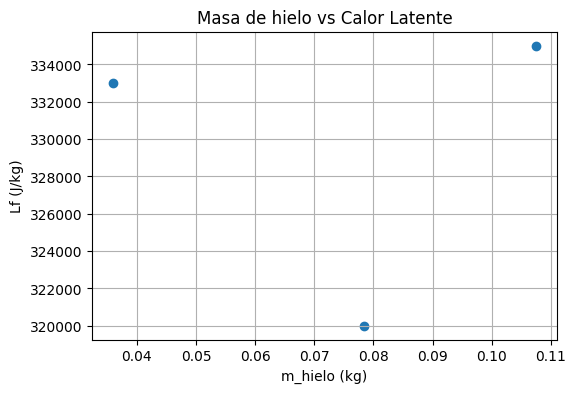

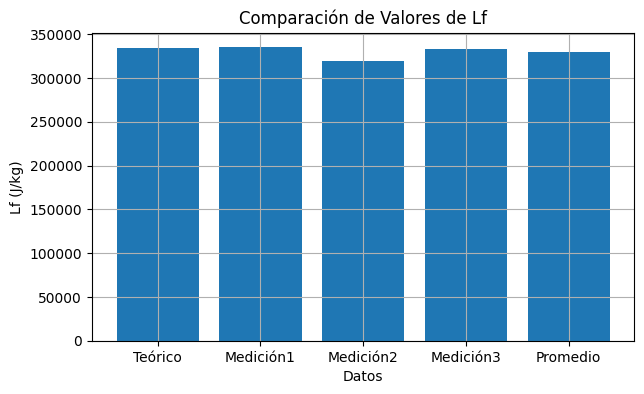

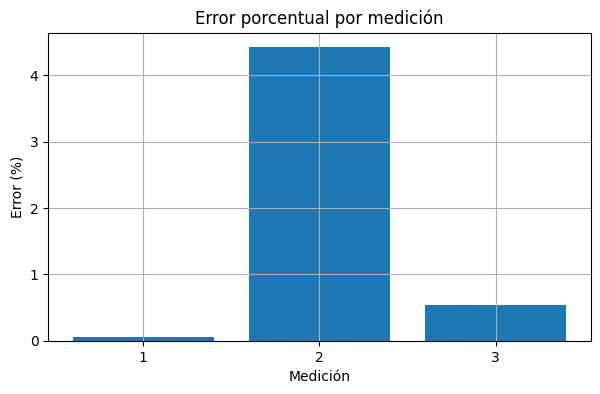

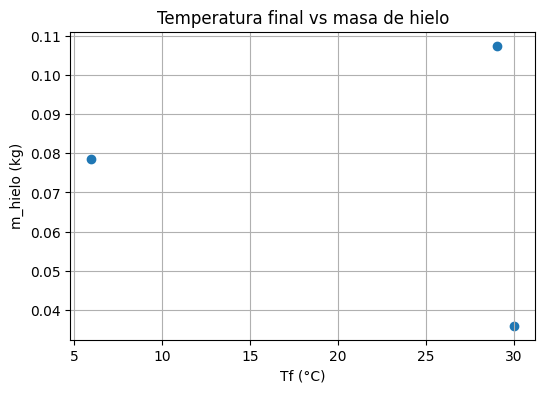

In [7]:

# =========================================================
# IMPORTACIÓN DE LIBRERÍAS
# =========================================================
#BLOQUE 2
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod

# =========================================================
# CLASE ABSTRACTA BASE
# =========================================================

class GraficaBase(ABC):

    def __init__(self, titulo, xlabel, ylabel):

        self.titulo = titulo
        self.xlabel = xlabel
        self.ylabel = ylabel

    def configurar_grafica(self):

        plt.title(self.titulo)

        plt.xlabel(self.xlabel)

        plt.ylabel(self.ylabel)

        plt.grid(True)

    @abstractmethod
    def graficar(self):
        pass


# =========================================================
# CLASE HIJA: DISPERSIÓN
# =========================================================

class GraficaDispersion(GraficaBase):

    def __init__(self, x, y,
                 titulo, xlabel, ylabel):

        super().__init__(titulo, xlabel, ylabel)

        self.x = np.array(x)
        self.y = np.array(y)

    def graficar(self):

        plt.figure(figsize=(6,4))

        plt.scatter(self.x, self.y)

        self.configurar_grafica()

        plt.show()


# =========================================================
# CLASE HIJA: LÍNEA
# =========================================================

class GraficaLinea(GraficaBase):

    def __init__(self, x, y, linea,
                 titulo, xlabel, ylabel):

        super().__init__(titulo, xlabel, ylabel)

        self.x = np.array(x)
        self.y = np.array(y)
        self.linea = linea

    def graficar(self):

        plt.figure(figsize=(6,4))

        plt.scatter(self.x, self.y)

        plt.plot(
            [min(self.x), max(self.x)],
            [self.linea, self.linea]
        )

        self.configurar_grafica()

        plt.show()


# =========================================================
# CLASE HIJA: BARRAS
# =========================================================

class GraficaBarras(GraficaBase):

    def __init__(self, etiquetas, valores,
                 titulo, xlabel, ylabel):

        super().__init__(titulo, xlabel, ylabel)

        self.etiquetas = etiquetas
        self.valores = np.array(valores)

    def graficar(self):

        plt.figure(figsize=(7,4))

        plt.bar(self.etiquetas, self.valores)

        self.configurar_grafica()

        plt.show()


# =========================================================
# DATOS EXPERIMENTALES
# =========================================================

Ti = [78, 66.6, 82]

Tf = [29, 6, 30]

m_hielo = [0.10745, 0.07845, 0.03596]

Lf = [3.35e5, 3.20e5, 3.33e5]

L_teorico = 3.348e5

promedio = np.mean(Lf)

errores = [0.06, 4.42, 0.54]


# =========================================================
# GRÁFICA 1
# =========================================================

grafica1 = GraficaLinea(

    x=Ti,

    y=Lf,

    linea=333000,

    titulo="Temperatura inicial vs Calor Latente",

    xlabel="Ti (°C)",

    ylabel="Lf (J/kg)"
)

grafica1.graficar()


# =========================================================
# GRÁFICA 2
# =========================================================

grafica2 = GraficaDispersion(

    x=m_hielo,

    y=Lf,

    titulo="Masa de hielo vs Calor Latente",

    xlabel="m_hielo (kg)",

    ylabel="Lf (J/kg)"
)

grafica2.graficar()


# =========================================================
# GRÁFICA 3
# =========================================================

grafica3 = GraficaBarras(

    etiquetas=[
        "Teórico",
        "Medición1",
        "Medición2",
        "Medición3",
        "Promedio"
    ],

    valores=[
        L_teorico,
        Lf[0],
        Lf[1],
        Lf[2],
        promedio
    ],

    titulo="Comparación de Valores de Lf",

    xlabel="Datos",

    ylabel="Lf (J/kg)"
)

grafica3.graficar()


# =========================================================
# GRÁFICA 4
# =========================================================

grafica4 = GraficaBarras(

    etiquetas=["1", "2", "3"],

    valores=errores,

    titulo="Error porcentual por medición",

    xlabel="Medición",

    ylabel="Error (%)"
)

grafica4.graficar()


# =========================================================
# GRÁFICA 5
# =========================================================

grafica5 = GraficaDispersion(

    x=Tf,

    y=m_hielo,

    titulo="Temperatura final vs masa de hielo",

    xlabel="Tf (°C)",

    ylabel="m_hielo (kg)"
)

grafica5.graficar()

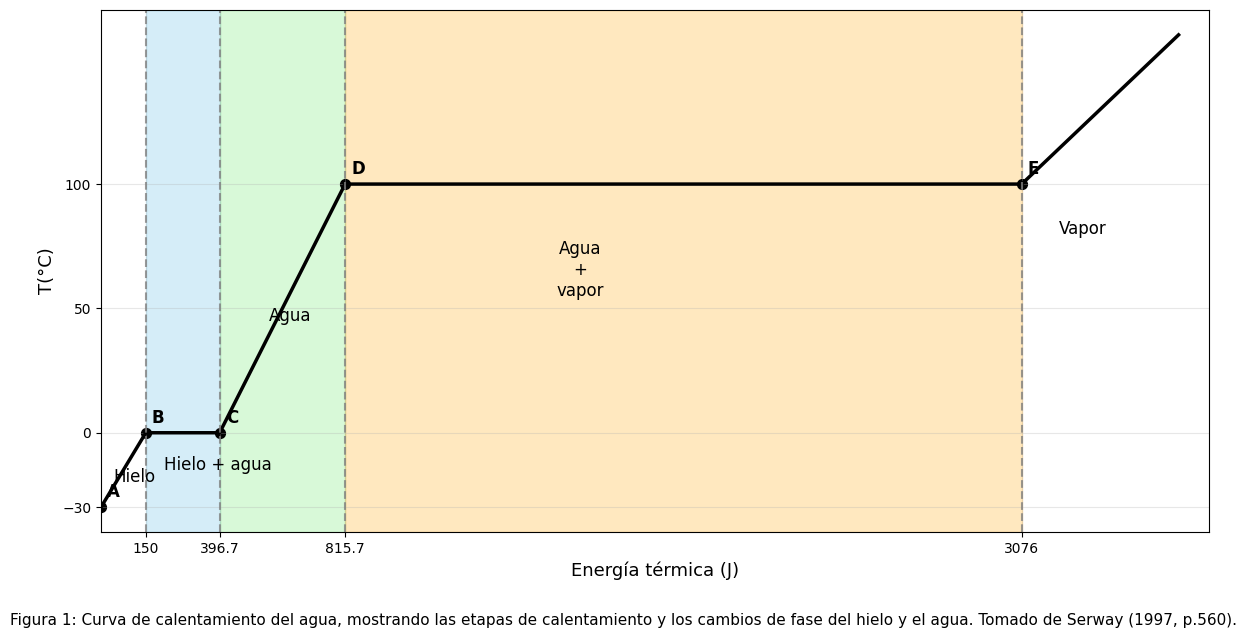

In [8]:
# =========================================================
# BLOQUE 3
# CURVA DE CALENTAMIENTO DEL AGUA
# =========================================================

import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# DATOS
# =========================================================

# Energía térmica (J)
# Se amplió la región A→B para evitar
# que los textos se solapen
x = [0, 150, 396.7, 815.7, 3076, 3600]

# Temperatura (°C)
y = [-30, 0, 0, 100, 100, 160]

# =========================================================
# CREAR FIGURA
# =========================================================

plt.figure(figsize=(12,6))

# =========================================================
# REGIONES COLOREADAS
# =========================================================

# Hielo + agua
plt.axvspan(
    150,
    396.7,
    color='skyblue',
    alpha=0.35
)

# Agua líquida
plt.axvspan(
    396.7,
    815.7,
    color='lightgreen',
    alpha=0.35
)

# Agua + vapor
plt.axvspan(
    815.7,
    3076,
    color='orange',
    alpha=0.25
)

# =========================================================
# CURVA PRINCIPAL
# =========================================================

plt.plot(
    x,
    y,
    color='black',
    linewidth=2.5
)

# =========================================================
# PUNTOS A, B, C, D, E
# =========================================================

puntos_x = [0, 150, 396.7, 815.7, 3076]

puntos_y = [-30, 0, 0, 100, 100]

labels = ['A', 'B', 'C', 'D', 'E']

plt.scatter(
    puntos_x,
    puntos_y,
    color='black',
    s=50
)

# =========================================================
# ETIQUETAS DE PUNTOS
# =========================================================

for i in range(len(labels)):

    plt.text(
        puntos_x[i] + 20,
        puntos_y[i] + 4,
        labels[i],
        fontsize=12,
        fontweight='bold'
    )

# =========================================================
# LÍNEAS VERTICALES PUNTEADAS
# =========================================================

for xc in [150, 396.7, 815.7, 3076]:

    plt.axvline(
        x=xc,
        linestyle='--',
        color='gray',
        alpha=0.8
    )

# =========================================================
# TEXTOS DE REGIONES
# =========================================================

# Hielo
plt.text(
    40,
    -20,
    'Hielo',
    fontsize=12
)

# Hielo + agua
plt.text(
    210,
    -15,
    'Hielo + agua',
    fontsize=12
)

# Agua líquida
plt.text(
    560,
    45,
    'Agua',
    fontsize=12
)

# Agua + vapor
plt.text(
    1600,
    55,
    'Agua\n+\nvapor',
    fontsize=12,
    ha='center'
)

# Vapor
plt.text(
    3200,
    80,
    'Vapor',
    fontsize=12
)

# =========================================================
# EJES
# =========================================================

plt.xlabel(
    'Energía térmica (J)',
    fontsize=13
)

plt.ylabel(
    'T(°C)',
    fontsize=13
)

# =========================================================
# LÍMITES
# =========================================================

plt.xlim(0, 3700)

plt.ylim(-40, 170)

# =========================================================
# TICKS PERSONALIZADOS
# =========================================================

plt.xticks(
    [150, 396.7, 815.7, 3076],
    ['150', '396.7', '815.7', '3076']
)

plt.yticks(
    [-30, 0, 50, 100]
)

# =========================================================
# GRID
# =========================================================

plt.grid(alpha=0.3)

# =========================================================
# CAPTION
# =========================================================

plt.figtext(
    0.5,
    -0.05,
    'Figura 1: Curva de calentamiento del agua, mostrando las etapas '
    'de calentamiento y los cambios de fase del hielo y el agua. '
    'Tomado de Serway (1997, p.560).',
    ha='center',
    fontsize=11
)

# =========================================================
# MOSTRAR
# =========================================================

plt.tight_layout()

plt.show()

In [ ]:
"""
Simulación Molecular del Agua — Cambio de Fase
Requiere: pip install pygame
Ejecutar: python simulacion_molecular_agua.py
"""

import pygame
import math
import random
import sys

# ── Configuración ──────────────────────────────────────────────────────────
WIDTH, HEIGHT = 760, 560
SIM_TOP = 120       # margen superior del área de simulación
SIM_H = 300         # altura del área de simulación
FPS = 60
COLS, ROWS = 6, 4

# Colores
WHITE       = (255, 255, 255)
BG_LIGHT    = (245, 247, 250)
CARD_BG     = (249, 250, 251)
BORDER      = (229, 231, 235)
TEXT_DARK   = ( 26,  26,  46)
TEXT_GRAY   = (107, 114, 128)
TEXT_LIGHT  = (156, 163, 175)

O_SOLID     = ( 29, 158, 117)
O_LIQUID    = ( 55, 138, 221)
O_GAS       = (216,  90,  48)
H_COLOR     = (133, 183, 235)
HBOND_COLOR = ( 90, 160, 255)
CBOND_COLOR = (160, 160, 180)

BADGE_SOLID  = ((225, 245, 238), ( 8,  80,  65))
BADGE_LIQUID = ((230, 241, 251), ( 4,  44,  83))
BADGE_GAS    = ((250, 236, 231), ( 74,  27,  12))

PHASE_BORDER = {'solid': (15,110, 86), 'liquid': (24, 95,165), 'gas': (216, 90, 48)}
PHASE_DESC_BG= {'solid': (240,255,248), 'liquid': (240,247,255), 'gas': (255,245,238)}

GRAD_SOLID  = [(238,248,255), (208,234,248)]
GRAD_LIQUID = [(227,244,251), (168,216,238)]
GRAD_GAS    = [(255,245,238), (253,220,200)]


# ── Datos de UI por fase ───────────────────────────────────────────────────
PHASE_DATA = {
    'solid': {
        'name': 'Hielo (sólido)', 'badge': 'SÓLIDO',
        'mobility': 'Muy baja — vibración',
        'distance': '~2.76 Å', 'energy': 'Mínima',
        'desc': (
            "HIELO: Las moléculas forman una red cristalina hexagonal estable. "
            "Cada H₂O establece hasta 4 enlaces de hidrógeno con sus vecinas, "
            "creando una estructura rígida y ordenada. El hielo es menos denso "
            "que el agua líquida porque la red hexagonal deja espacios vacíos."
        ),
    },
    'liquid': {
        'name': 'Agua (líquido)', 'badge': 'LÍQUIDO',
        'mobility': 'Media — fluye y difunde',
        'distance': '~2.82 Å', 'energy': 'Moderada',
        'desc': (
            "AGUA LÍQUIDA: Los enlaces de hidrógeno se rompen y forman "
            "continuamente. Las moléculas se desplazan libremente manteniendo "
            "cohesión parcial. La estructura es aleatoria y cambiante cada "
            "picosegundo."
        ),
    },
    'gas': {
        'name': 'Vapor (gaseoso)', 'badge': 'GAS',
        'mobility': 'Muy alta — movimiento libre',
        'distance': '> 30 Å (dispersas)', 'energy': 'Alta',
        'desc': (
            "VAPOR DE AGUA: Las moléculas tienen energía suficiente para escapar "
            "de los enlaces de hidrógeno. Se mueven de forma completamente libre "
            "e independiente. La densidad es ~1600 veces menor que en estado "
            "líquido."
        ),
    },
}


# ── Clase Molécula ─────────────────────────────────────────────────────────
class Molecule:
    def __init__(self, bx, by):
        self.bx = bx
        self.by = by
        self.x = float(bx)
        self.y = float(by)
        self.vx = (random.random() - 0.5) * 0.5
        self.vy = (random.random() - 0.5) * 0.5
        self.angle = random.random() * math.pi * 2
        self.av = (random.random() - 0.5) * 0.02

    def update(self, phase, temp, margin_x, margin_y, spacing_x, spacing_y,
               col, row, sim_left, sim_right, sim_top, sim_bottom):
        # Actualizar posición base
        offset = spacing_x * 0.5 if row % 2 == 1 else 0
        self.bx = margin_x + col * spacing_x + offset
        self.by = margin_y + row * spacing_y

        if phase == 'solid':
            jitter = 0.18 + (temp + 50) / 50 * 0.25
            angular_speed = 0.006 + (temp + 50) / 50 * 0.012
            attraction = 0.13
            damping = 0.82
        elif phase == 'liquid':
            lf = temp / 100
            jitter = 0.55 + lf * 1.0
            angular_speed = 0.025 + lf * 0.06
            attraction = 0.007
            damping = 0.93
        else:
            gf = (temp - 100) / 50
            jitter = 1.5 + gf * 3.5
            angular_speed = 0.08 + gf * 0.15
            attraction = 0.0
            damping = 0.975

        self.vx += (self.bx - self.x) * attraction + (random.random() - 0.5) * jitter
        self.vy += (self.by - self.y) * attraction + (random.random() - 0.5) * jitter
        self.vx *= damping
        self.vy *= damping
        self.x += self.vx
        self.y += self.vy
        self.angle += self.av + (random.random() - 0.5) * angular_speed

        # Rebotar en bordes
        if self.x < sim_left + 14:
            self.x = sim_left + 14; self.vx *= -0.5
        if self.x > sim_right - 14:
            self.x = sim_right - 14; self.vx *= -0.5
        if self.y < sim_top + 14:
            self.y = sim_top + 14; self.vy *= -0.5
        if self.y > sim_bottom - 14:
            self.y = sim_bottom - 14; self.vy *= -0.5


# ── Funciones auxiliares ───────────────────────────────────────────────────
def get_phase(temp):
    if temp < 0:
        return 'solid'
    if temp < 100:
        return 'liquid'
    return 'gas'


def lerp_color(c1, c2, t):
    return tuple(int(c1[i] + (c2[i] - c1[i]) * t) for i in range(3))


def draw_gradient_rect(surf, rect, color_top, color_bottom):
    x, y, w, h = rect
    for i in range(h):
        t = i / max(h - 1, 1)
        color = lerp_color(color_top, color_bottom, t)
        pygame.draw.line(surf, color, (x, y + i), (x + w - 1, y + i))


def draw_rounded_rect(surf, color, rect, radius, border_color=None, border_width=1):
    pygame.draw.rect(surf, color, rect, border_radius=radius)
    if border_color:
        pygame.draw.rect(surf, border_color, rect, border_width, border_radius=radius)


def draw_text(surf, text, font, color, x, y, align='left'):
    rendered = font.render(text, True, color)
    if align == 'center':
        x -= rendered.get_width() // 2
    elif align == 'right':
        x -= rendered.get_width()
    surf.blit(rendered, (x, y))
    return rendered.get_width()


def wrap_text(text, font, max_width):
    words = text.split()
    lines = []
    current = []
    for word in words:
        test = ' '.join(current + [word])
        if font.size(test)[0] <= max_width:
            current.append(word)
        else:
            if current:
                lines.append(' '.join(current))
            current = [word]
    if current:
        lines.append(' '.join(current))
    return lines


# ── Simulación principal ───────────────────────────────────────────────────
def main():
    pygame.init()
    screen = pygame.display.set_mode((WIDTH, HEIGHT))
    pygame.display.set_caption("Simulación Molecular del Agua — Cambio de Fase")
    clock = pygame.time.Clock()

    # Fuentes
    font_title  = pygame.font.SysFont('Arial', 17, bold=True)
    font_large  = pygame.font.SysFont('Arial', 26, bold=True)
    font_medium = pygame.font.SysFont('Arial', 17, bold=True)
    font_small  = pygame.font.SysFont('Arial', 12)
    font_label  = pygame.font.SysFont('Arial', 11)
    font_badge  = pygame.font.SysFont('Arial', 12, bold=True)
    font_desc   = pygame.font.SysFont('Arial', 12)

    # Área de simulación
    SIM_LEFT   = 24
    SIM_RIGHT  = WIDTH - 24
    SIM_BOTTOM = SIM_TOP + SIM_H
    SIM_W      = SIM_RIGHT - SIM_LEFT

    MARGIN_X = SIM_W * 0.07
    MARGIN_Y = SIM_H * 0.10
    SPACING_X = (SIM_W - 2 * MARGIN_X) / (COLS - 1)
    SPACING_Y = (SIM_H - 2 * MARGIN_Y) / (ROWS - 1)

    # Inicializar moléculas
    def init_molecules():
        mols = []
        for r in range(ROWS):
            for c in range(COLS):
                offset = SPACING_X * 0.5 if r % 2 == 1 else 0
                bx = SIM_LEFT + MARGIN_X + c * SPACING_X + offset
                by = SIM_TOP + MARGIN_Y + r * SPACING_Y
                mols.append(Molecule(bx, by))
        return mols

    molecules = init_molecules()

    # Slider
    temp = -30
    SLIDER_X = 110
    SLIDER_Y = 78
    SLIDER_W = WIDTH - 130
    SLIDER_H = 6
    dragging = False

    def temp_to_slider_x(t):
        return SLIDER_X + int((t + 50) / 200 * SLIDER_W)

    def slider_x_to_temp(sx):
        return round(-50 + (sx - SLIDER_X) / SLIDER_W * 200)

    # Superficie de simulación (para gradiente de fondo)
    sim_surf = pygame.Surface((SIM_W, SIM_H))

    running = True
    while running:
        clock.tick(FPS)
        phase = get_phase(temp)
        pd = PHASE_DATA[phase]

        # ── Eventos ────────────────────────────────────────────────────────
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
            elif event.type == pygame.KEYDOWN and event.key == pygame.K_ESCAPE:
                running = False
            elif event.type == pygame.MOUSEBUTTONDOWN:
                mx, my = event.pos
                handle_x = temp_to_slider_x(temp)
                if abs(mx - handle_x) < 12 and abs(my - SLIDER_Y) < 12:
                    dragging = True
                # Clic en la barra
                elif (SLIDER_X <= mx <= SLIDER_X + SLIDER_W and
                      abs(my - SLIDER_Y) < 10):
                    temp = max(-50, min(150, slider_x_to_temp(mx)))
            elif event.type == pygame.MOUSEBUTTONUP:
                dragging = False
            elif event.type == pygame.MOUSEMOTION and dragging:
                mx = max(SLIDER_X, min(SLIDER_X + SLIDER_W, event.pos[0]))
                temp = slider_x_to_temp(mx)

        # ── Actualizar moléculas ───────────────────────────────────────────
        for i, m in enumerate(molecules):
            row = i // COLS
            col = i % COLS
            m.update(phase, temp,
                     SIM_LEFT + MARGIN_X, SIM_TOP + MARGIN_Y,
                     SPACING_X, SPACING_Y,
                     col, row,
                     SIM_LEFT, SIM_RIGHT, SIM_TOP, SIM_BOTTOM)

        # ── Dibujar ────────────────────────────────────────────────────────
        screen.fill(BG_LIGHT)

        # Tarjeta principal
        draw_rounded_rect(screen, WHITE, (12, 12, WIDTH - 24, HEIGHT - 24),
                          16, BORDER)

        # Título
        draw_text(screen, "Simulación Molecular del Agua — Cambio de Fase",
                  font_title, TEXT_DARK, 30, 26)

        # Label del slider
        draw_text(screen, "Temperatura", font_small, TEXT_GRAY, 30, SLIDER_Y - 8)

        # Barra del slider
        bar_rect = pygame.Rect(SLIDER_X, SLIDER_Y - 3, SLIDER_W, SLIDER_H)
        pygame.draw.rect(screen, BORDER, bar_rect, border_radius=3)
        # Relleno azul hasta la posición actual
        fill_w = temp_to_slider_x(temp) - SLIDER_X
        if fill_w > 0:
            pygame.draw.rect(screen, O_LIQUID,
                             (SLIDER_X, SLIDER_Y - 3, fill_w, SLIDER_H),
                             border_radius=3)
        # Handle
        hx = temp_to_slider_x(temp)
        pygame.draw.circle(screen, O_LIQUID, (hx, SLIDER_Y), 8)
        pygame.draw.circle(screen, WHITE, (hx, SLIDER_Y), 5)

        # Marcadores de temperatura
        markers = [(-50, '-50°C'), (0, '0°C'), (50, '50°C'),
                   (100, '100°C'), (150, '150°C')]
        for mt, ml in markers:
            mx2 = temp_to_slider_x(mt)
            draw_text(screen, ml, font_label, TEXT_LIGHT, mx2, SLIDER_Y + 10, 'center')
            pygame.draw.line(screen, TEXT_LIGHT, (mx2, SLIDER_Y + 4), (mx2, SLIDER_Y + 7))

        # Fila de temperatura y fase
        tx = 30
        ty = SIM_TOP - 32
        tw = draw_text(screen, f"{temp}°C", font_large, TEXT_DARK, tx, ty)
        draw_text(screen, "→", font_medium, TEXT_GRAY, tx + tw + 8, ty + 4)
        draw_text(screen, pd['name'], font_medium, TEXT_DARK,
                  tx + tw + 28, ty + 4)

        # Badge
        badge_text = pd['badge']
        badge_surf = font_badge.render(badge_text, True, BADGE_SOLID[1]
                                       if phase == 'solid' else
                                       BADGE_LIQUID[1] if phase == 'liquid' else
                                       BADGE_GAS[1])
        bw = badge_surf.get_width() + 20
        bh = 22
        bx2 = tx + tw + 28 + font_medium.size(pd['name'])[0] + 12
        by2 = ty + 2
        badge_bg = (BADGE_SOLID[0] if phase == 'solid' else
                    BADGE_LIQUID[0] if phase == 'liquid' else BADGE_GAS[0])
        pygame.draw.rect(screen, badge_bg,
                         (bx2, by2, bw, bh), border_radius=11)
        screen.blit(badge_surf, (bx2 + 10, by2 + 4))

        # ── Fondo del área de simulación ───────────────────────────────────
        grad = GRAD_SOLID if phase == 'solid' else \
               GRAD_LIQUID if phase == 'liquid' else GRAD_GAS
        draw_gradient_rect(sim_surf,
                           (0, 0, SIM_W, SIM_H),
                           grad[0], grad[1])
        screen.blit(sim_surf, (SIM_LEFT, SIM_TOP))
        pygame.draw.rect(screen, BORDER,
                         (SIM_LEFT, SIM_TOP, SIM_W, SIM_H),
                         1, border_radius=10)

        # ── Enlaces de hidrógeno ───────────────────────────────────────────
        if phase != 'gas':
            threshold = 108 if phase == 'solid' else 88
            alpha = (0.55 if phase == 'solid' else
                     max(0.08, 0.45 - (temp / 100) * 0.32))
            hbond_color = tuple(int(c * alpha + bg * (1 - alpha))
                                for c, bg in zip(HBOND_COLOR, grad[0]))
            for i in range(len(molecules)):
                for j in range(i + 1, len(molecules)):
                    mi, mj = molecules[i], molecules[j]
                    dx = mj.x - mi.x
                    dy = mj.y - mi.y
                    dist = math.sqrt(dx * dx + dy * dy)
                    if dist < threshold:
                        # Línea punteada manual
                        steps = int(dist / 8)
                        for s in range(steps):
                            if s % 2 == 0:
                                x1 = int(mi.x + dx * s / max(steps, 1))
                                y1 = int(mi.y + dy * s / max(steps, 1))
                                x2 = int(mi.x + dx * (s + 1) / max(steps, 1))
                                y2 = int(mi.y + dy * (s + 1) / max(steps, 1))
                                pygame.draw.line(screen, hbond_color,
                                                 (x1, y1), (x2, y2), 1)

        # ── Moléculas ──────────────────────────────────────────────────────
        bond_len = 16
        h_angle = math.pi * 0.35
        r_O, r_H = 9, 6

        o_color = (O_SOLID if phase == 'solid' else
                   O_LIQUID if phase == 'liquid' else O_GAS)

        for m in molecules:
            angle = m.angle
            h1x = int(m.x + math.cos(angle - h_angle) * bond_len)
            h1y = int(m.y + math.sin(angle - h_angle) * bond_len)
            h2x = int(m.x + math.cos(angle + h_angle) * bond_len)
            h2y = int(m.y + math.sin(angle + h_angle) * bond_len)
            mx_i, my_i = int(m.x), int(m.y)

            # Enlace covalente
            pygame.draw.line(screen, CBOND_COLOR, (mx_i, my_i), (h1x, h1y), 2)
            pygame.draw.line(screen, CBOND_COLOR, (mx_i, my_i), (h2x, h2y), 2)
            # Hidrógenos
            pygame.draw.circle(screen, H_COLOR, (h1x, h1y), r_H)
            pygame.draw.circle(screen, (0, 0, 0), (h1x, h1y), r_H, 1)
            pygame.draw.circle(screen, H_COLOR, (h2x, h2y), r_H)
            pygame.draw.circle(screen, (0, 0, 0), (h2x, h2y), r_H, 1)
            # Oxígeno
            pygame.draw.circle(screen, o_color, (mx_i, my_i), r_O)
            pygame.draw.circle(screen, (0, 0, 0), (mx_i, my_i), r_O, 1)
            # Brillo
            pygame.draw.circle(screen, (255, 255, 255, 140),
                                (mx_i - 2, my_i - 2), 3)

        # ── Leyenda ────────────────────────────────────────────────────────
        legend_y = SIM_TOP + SIM_H + 10
        items = [
            (O_SOLID,  'O — sólido'),
            (O_LIQUID, 'O — líquido'),
            (O_GAS,    'O — gas'),
            (H_COLOR,  'Hidrógeno (H)'),
        ]
        lx = 30
        for color, label in items:
            pygame.draw.circle(screen, color, (lx + 6, legend_y + 6), 6)
            draw_text(screen, label, font_label, TEXT_GRAY, lx + 16, legend_y)
            lx += font_label.size(label)[0] + 32

        # Enlace de hidrógeno
        pygame.draw.line(screen, HBOND_COLOR, (lx, legend_y + 6), (lx + 28, legend_y + 6), 2)
        draw_text(screen, 'Enlace H', font_label, TEXT_GRAY, lx + 32, legend_y)
        lx += font_label.size('Enlace H')[0] + 68
        pygame.draw.line(screen, CBOND_COLOR, (lx, legend_y + 6), (lx + 28, legend_y + 6), 2)
        draw_text(screen, 'Enlace O-H', font_label, TEXT_GRAY, lx + 32, legend_y)

        # ── Tarjetas de info ───────────────────────────────────────────────
        card_y = legend_y + 26
        card_h = 52
        card_w = (WIDTH - 60) // 3
        info_items = [
            ('Movilidad molecular', pd['mobility']),
            ('Distancia promedio', pd['distance']),
            ('Energía cinética', pd['energy']),
        ]
        for idx, (lbl, val) in enumerate(info_items):
            cx = 30 + idx * (card_w + 6)
            draw_rounded_rect(screen, CARD_BG,
                               (cx, card_y, card_w, card_h), 8, BORDER)
            draw_text(screen, lbl, font_label, TEXT_LIGHT, cx + 10, card_y + 8)
            draw_text(screen, val, font_small, TEXT_DARK, cx + 10, card_y + 26)

        # ── Caja de descripción ────────────────────────────────────────────
        desc_y = card_y + card_h + 10
        desc_h = HEIGHT - desc_y - 20
        desc_bg = PHASE_DESC_BG[phase]
        border_col = PHASE_BORDER[phase]
        desc_rect = (30, desc_y, WIDTH - 60, desc_h)
        draw_rounded_rect(screen, desc_bg, desc_rect, 8)
        pygame.draw.rect(screen, border_col,
                         (30, desc_y, 3, desc_h), border_radius=2)

        lines = wrap_text(pd['desc'], font_desc, WIDTH - 80)
        for li, line in enumerate(lines[:4]):
            draw_text(screen, line, font_desc, TEXT_DARK, 42, desc_y + 8 + li * 16)

        pygame.display.flip()

    pygame.quit()
    sys.exit()


if __name__ == '__main__':
    main()


pygame 2.6.1 (SDL 2.28.4, Python 3.12.13)
Hello from the pygame community. https://www.pygame.org/contribute.html
